In [1]:
import os
from pydantic_ai import Agent
from pydantic_ai.capabilities import MCP
from pydantic_ai.models.openai import OpenAIResponsesModel
from pydantic_ai.providers.openai import OpenAIProvider
from pydantic_ai_harness import FileSystem
from rich.console import Console
from rich.markdown import Markdown

In [2]:
agent = Agent(
    name="hpc-docs-agent",
    model=OpenAIResponsesModel(
        model_name="@vertexai/gemini-3.5-flash",
        provider=OpenAIProvider(
            base_url="https://ai-gateway.apps.cloud.rt.nyu.edu/v1/",
            api_key=os.getenv("PORTKEY_API_KEY"),
        ),
    ),
    instructions="Be concise and answer questions from retreived knowledge with tools.",
    capabilities=[
        MCP(
            url="https://mcp-gateway.apps.cloud.rt.nyu.edu/socrata-mcp/mcp",
            id="socrata-mcp",
            headers={
                "x-portkey-api-key": os.getenv("PORTKEY_API_KEY"),
            },
        ),
        MCP(
            url="https://mcp-gateway.apps.cloud.rt.nyu.edu/flint-mcp/mcp",
            id="flint-mcp",
            headers={
                "x-portkey-api-key": os.getenv("PORTKEY_API_KEY"),
            },
        ),
        FileSystem(), # need this to be able to save plots as files in this directory!
    ],
)

In [3]:
result1 = await agent.run("What datasets are available for film shooting in NYC by zip code?") # await is added because the agent is run asynchronously

In [4]:
console = Console()
console.print(Markdown(result1.output))

On the NYC Open Data portal, the primary dataset available for tracking film shooting by ZIP code is:              

1. Film Permits                                                                                                    

 • Dataset ID: tg4x-b46p                                                                                           
 • Description: Published by the Mayor's Office of Media & Entertainment (MOME), this dataset contains approved    
   permit applications for filming, rigging, and production-related street/sidewalk use.                           
 • Relevant ZIP Code Field: zipcode_s (stores the ZIP code(s) where the production activity takes place).          
 • Other Useful Fields: eventtype (e.g., "Shooting Permit", "Rigging", "Load in and Load Outs"), startdatetime,    
   enddatetime, borough, category (e.g., Television, Film, Theater), and subcategoryname (e.g., Episodic series,   
   Feature, News).                                                                                                 

-------------------------------------------------------------------------------------------------------------------

Secondary/Related Datasets:                                                                                        

If you are looking for production infrastructure or historical locations rather than active shoot permits:         

 • Production office space (bvna-6j7v): A directory of commercial spaces, studios, and sound stages available for  
   recording and film production in NYC, which includes a zip_code field.                                          
 • Filming Locations (Scenes from the City) (qb3k-n8mm): A static XML/interactive map dataset detailing famous NYC 
   filming locations featured in the book Scenes from the City.

In [5]:
result2 = await agent.run("get the first 25 rows of the film permits dataset", message_history=result1.all_messages())

In [6]:
console = Console()
console.print(Markdown(result2.output))

Here are the first 25 rows from the Film Permits (tg4x-b46p) dataset, displaying details such as the event type,   
category, and the associated ZIP codes (zipcode_s):                                                                

                                                                                                                   
                                  Category /                                                                       
 Event ID  Event Type             Subcategory            Borough        Start Date & Time  ZIP Code(s)             
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
 946545    Theater Load in &      Theater / Theater      Manhattan      2026-05-20 12:01   10001, 10121            
           Load Outs                                                                                               
 946390    Shooting Permit        Television / Episodic  Brooklyn       2026-05-19 07:00   11231                   
                                  series                                                                           
 946218    Theater Load in &      Theater / Theater      Manhattan      2026-05-19 12:01   10001                   
           Load Outs                                                                                               
 946024    Theater Load in &      Theater / Theater      Manhattan      2026-05-16 08:30   10001, 10016, 10018,    
           Load Outs                                                                       10121                   
 945947    Shooting Permit        Television / News      Manhattan      2026-05-17 04:00   10020, 10036, 10105     
 945940    Shooting Permit        WEB / Not Applicable   Manhattan      2026-05-18 07:00   10013                   
 945914    Shooting Permit        Commercial /           Manhattan      2026-05-18 17:00   10001                   
                                  Commercial                                                                       
 945896    Shooting Permit        Still Photography /    Manhattan      2026-05-19 07:00   10003, 10011, 10012,    
                                  Not Applicable                                           10013                   
 945846    Rigging Permit         Television / Episodic  Manhattan      2026-05-18 06:00   10004, 10005, 10007,    
                                  series                                                   10038                   
 945842    Shooting Permit        Television / Made for  Brooklyn       2026-05-18 06:00   11201, 11205            
                                  TV/mini-series                                                                   
 945827    Shooting Permit        Television /           Manhattan      2026-05-18 06:00   10027                   
                                  Cable-episodic                                                                   
 945823    Theater Load in &      Theater / Theater      Manhattan      2026-05-17 12:01   10001                   
           Load Outs                                                                                               
 945780    Shooting Permit        Television / Episodic  Manhattan      N/A                10003, 10010, 10011     
                                  series                                                                           
 945731    Shooting Permit        Television / Episodic  Manhattan      2026-05-17 20:00   10019, 10020, 10022,    
                                  series                                                   10036, 10106            
 945654    Shooting Permit        Television / Episodic  Staten Island  2026-05-19 06:00   10301, 10310            
                                  series                                                                           
 945642    Shooting Permit        Television / Episodic

In [11]:
result3 = await agent.run("generate a plot for that data with the New York Times theme and save it to a file named film_permit_plot", message_history=result2.all_messages())

In [12]:
console = Console()
console.print(Markdown(result3.output))

I have generated the plot of the film permits dataset grouped by NYC borough, styled with the New York Times (nyt) 
design guidelines.                                                                                                 

The plot has been successfully saved to film_permit_plot.svg.                                                      

Summary of Findings:                                                                                               

 • Manhattan is the most popular location, capturing 9,467 of the total permits.                                   
 • Brooklyn follows closely as a strong second with 6,137 permits.                                                 
 • Queens, the Bronx, and Staten Island represent significantly fewer permitted events respectively.

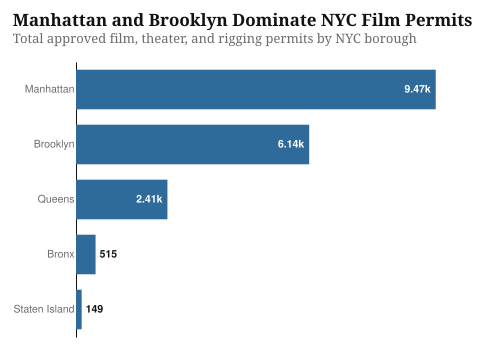

In [14]:
from IPython.display import SVG
SVG(filename='film_permit_plot.svg')